In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../data/framingham.csv')

In [10]:
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Vamos a ver la distribucion de la variable objetivo 

In [ ]:
df['TenYearCHD'].value_counts() 

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

podemos ver que de 4240 registros, 3596 no tienen riesgo de desarrollar enfermedad coronaria a 10 años, mientras que 644 si tienen riesgo.

A pesar de que el documento nos muestra los datos nulos por columna, vamos a mostrarlos

In [8]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


 # ANÁLISIS UNIVARIADO

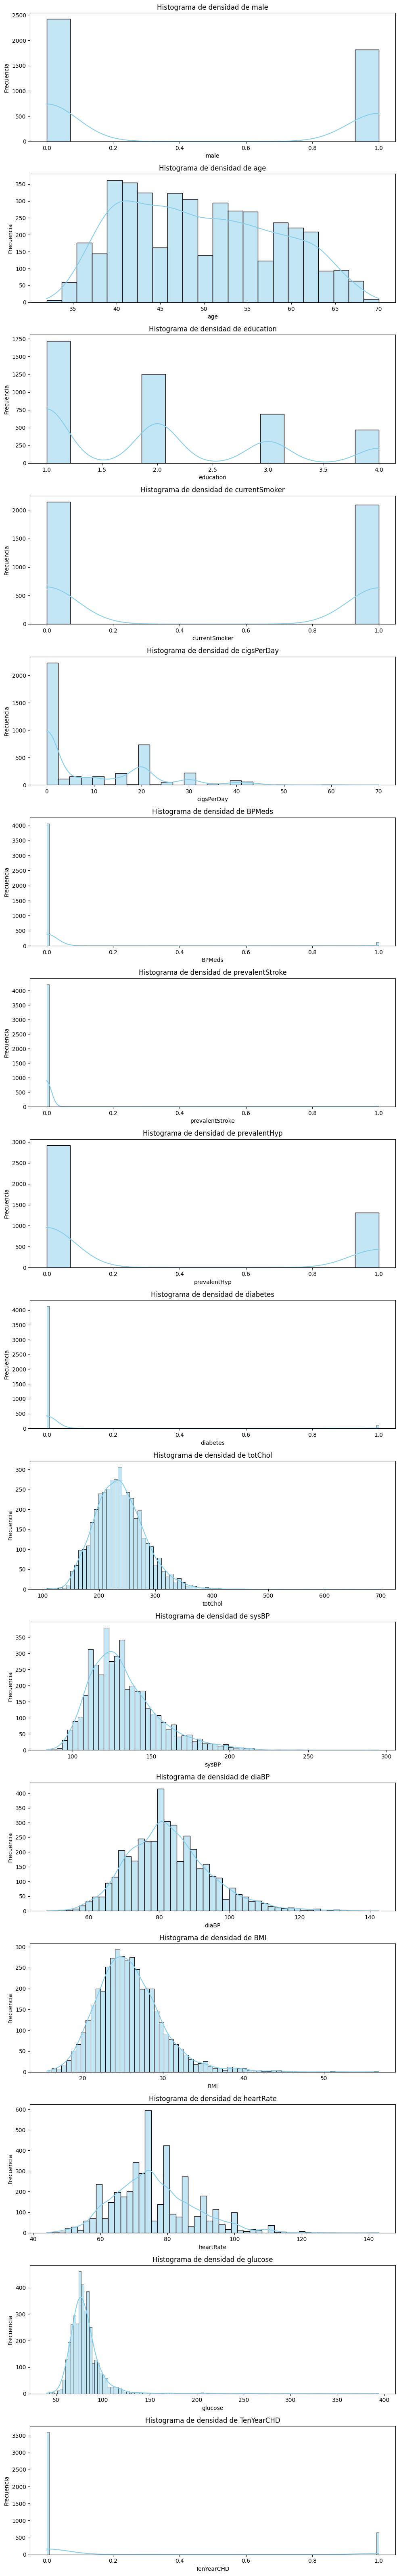

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns #ESTE FRAGMENTO DE CÓDIGO LO HE RECICLADO DEL EDA DE HOTEL BOOKINGS


n_rows = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(10, 4 * n_rows))


for i, column in enumerate(numeric_cols):
    sns.histplot(df[column].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histograma de densidad de {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Podemos ver que hay columnas que muestran solo dos barras, esto se debe a que son datos del tipo binario y categoricas. También podemos ver que variables como cigarretes perday tienen muchos valores en el 0, y menos valores a medida que la cantidad aumenta, salvando un pico en el 20. Esto lo veremos más a detalle.

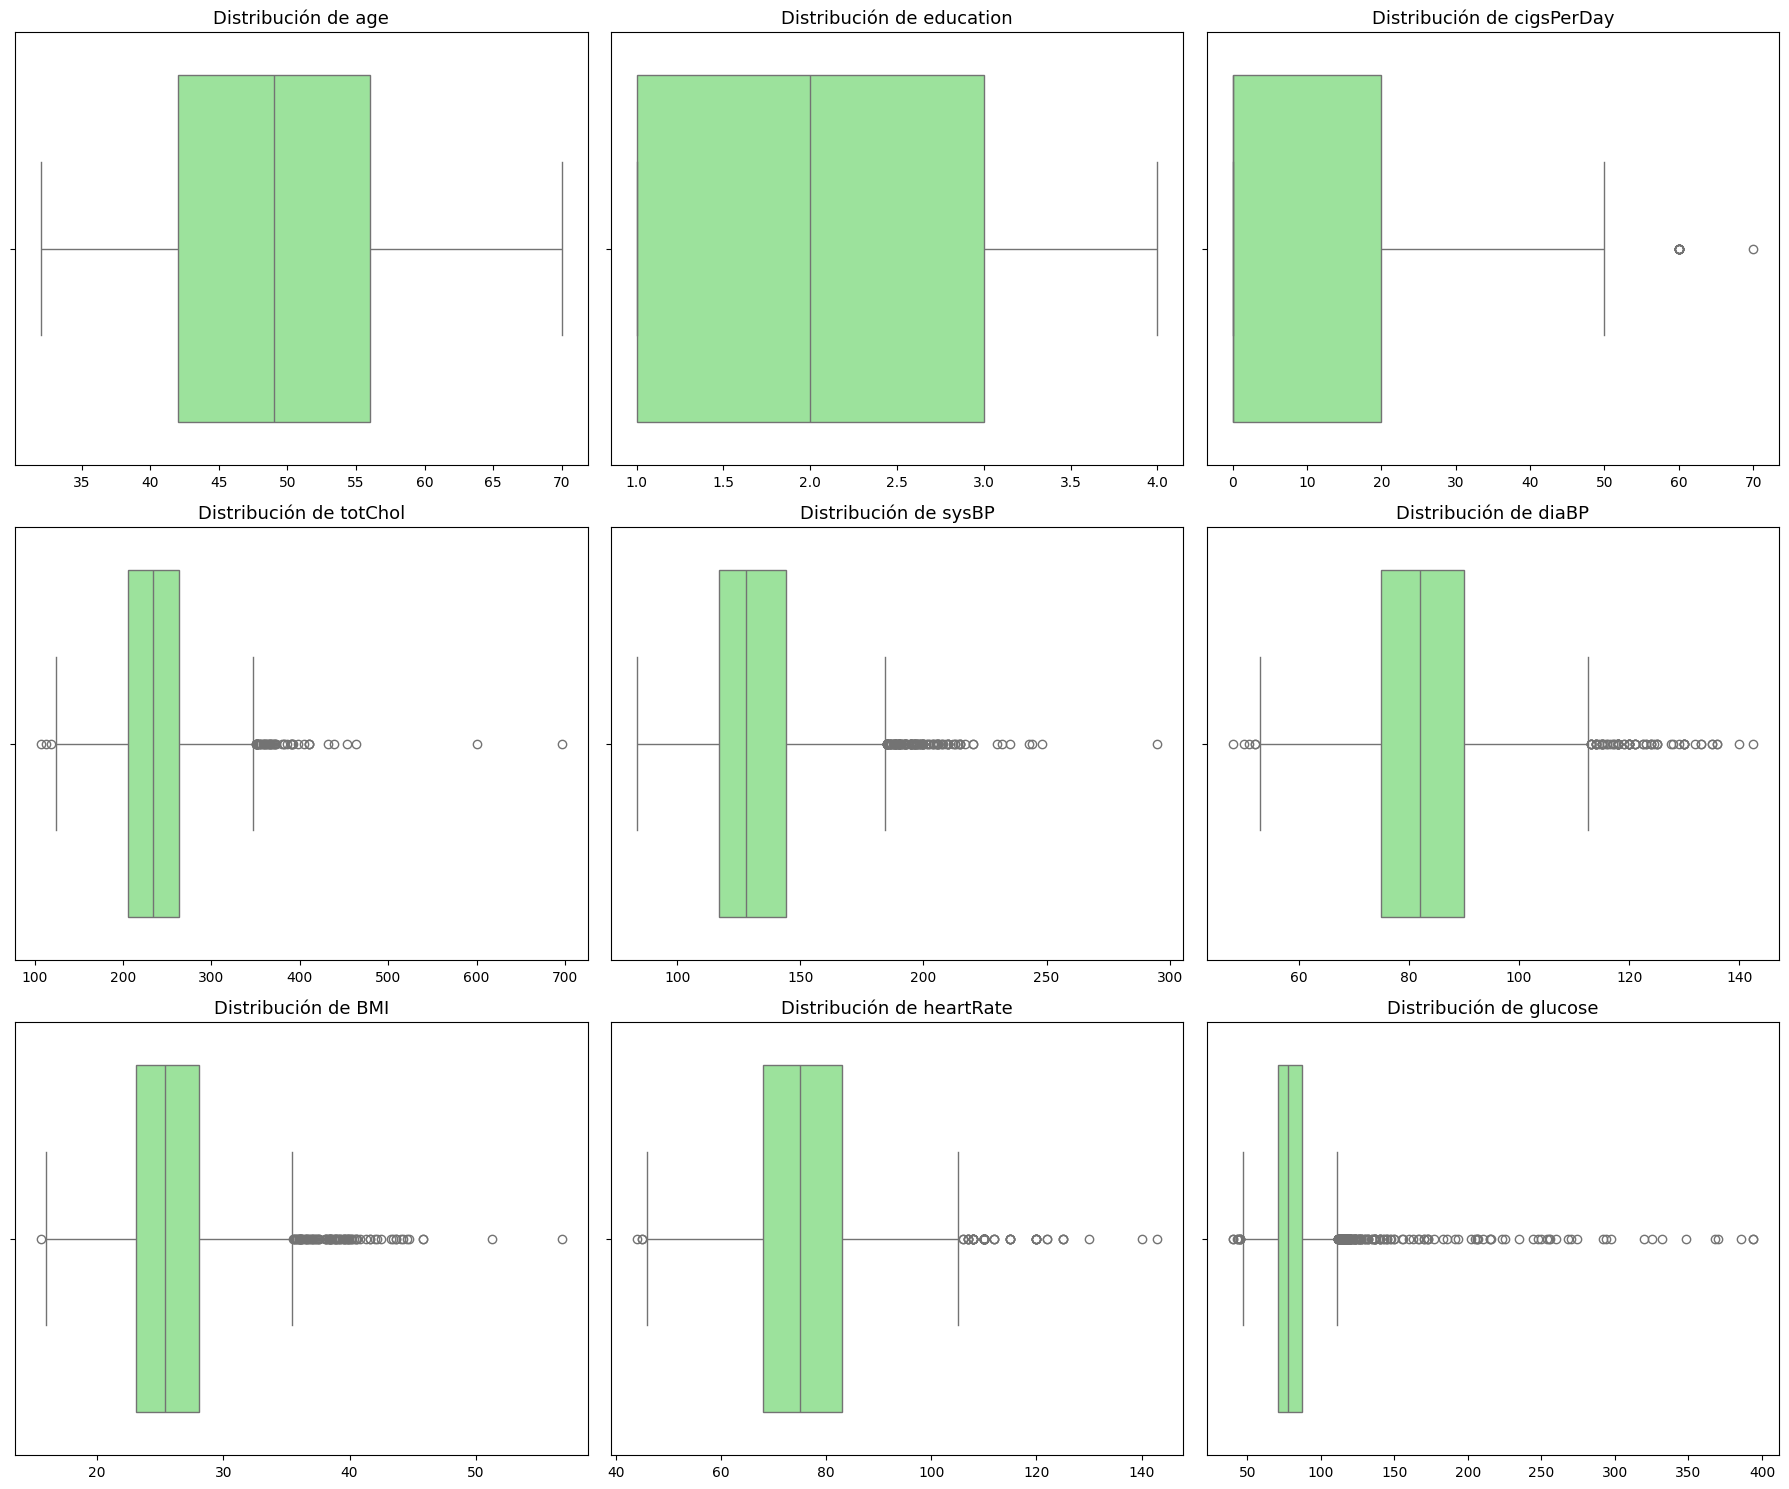

In [14]:


# Esto me lo paso la IA, para que no me haga los boxplots de las variables binarias
no_binarias = [col for col in df.columns if df[col].nunique() > 2]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(no_binarias):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', fliersize=6)
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

Llama la atención la cantidad de outliers que tiene laa columnas "glucose", "BMI", "sysBP", y "diaBP"

## Análisis de columnas categóricas

Vamos a tener que transformar las variables Bianrias a categóricas para su posterior análisis.

In [15]:

df['male'] = df['male'].astype('object')
df['currentSmoker'] = df['currentSmoker'].astype('object')  
df['BPMeds'] = df['BPMeds'].astype('object')  
df['prevalentStroke'] = df['prevalentStroke'].astype('object')  
df['prevalentHyp'] = df['prevalentHyp'].astype('object')  
df['diabetes'] = df['diabetes'].astype('object')  
df['TenYearCHD'] = df['TenYearCHD'].astype('object')  

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   object 
 6   prevalentStroke  4240 non-null   object 
 7   prevalentHyp     4240 non-null   object 
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   object 
dtypes: float64(8), int64(1), object(7)
memory usage: 530.1+ KB


Ahora podemos hacer el análisis univariante de las categóricas usando gráficos de barras

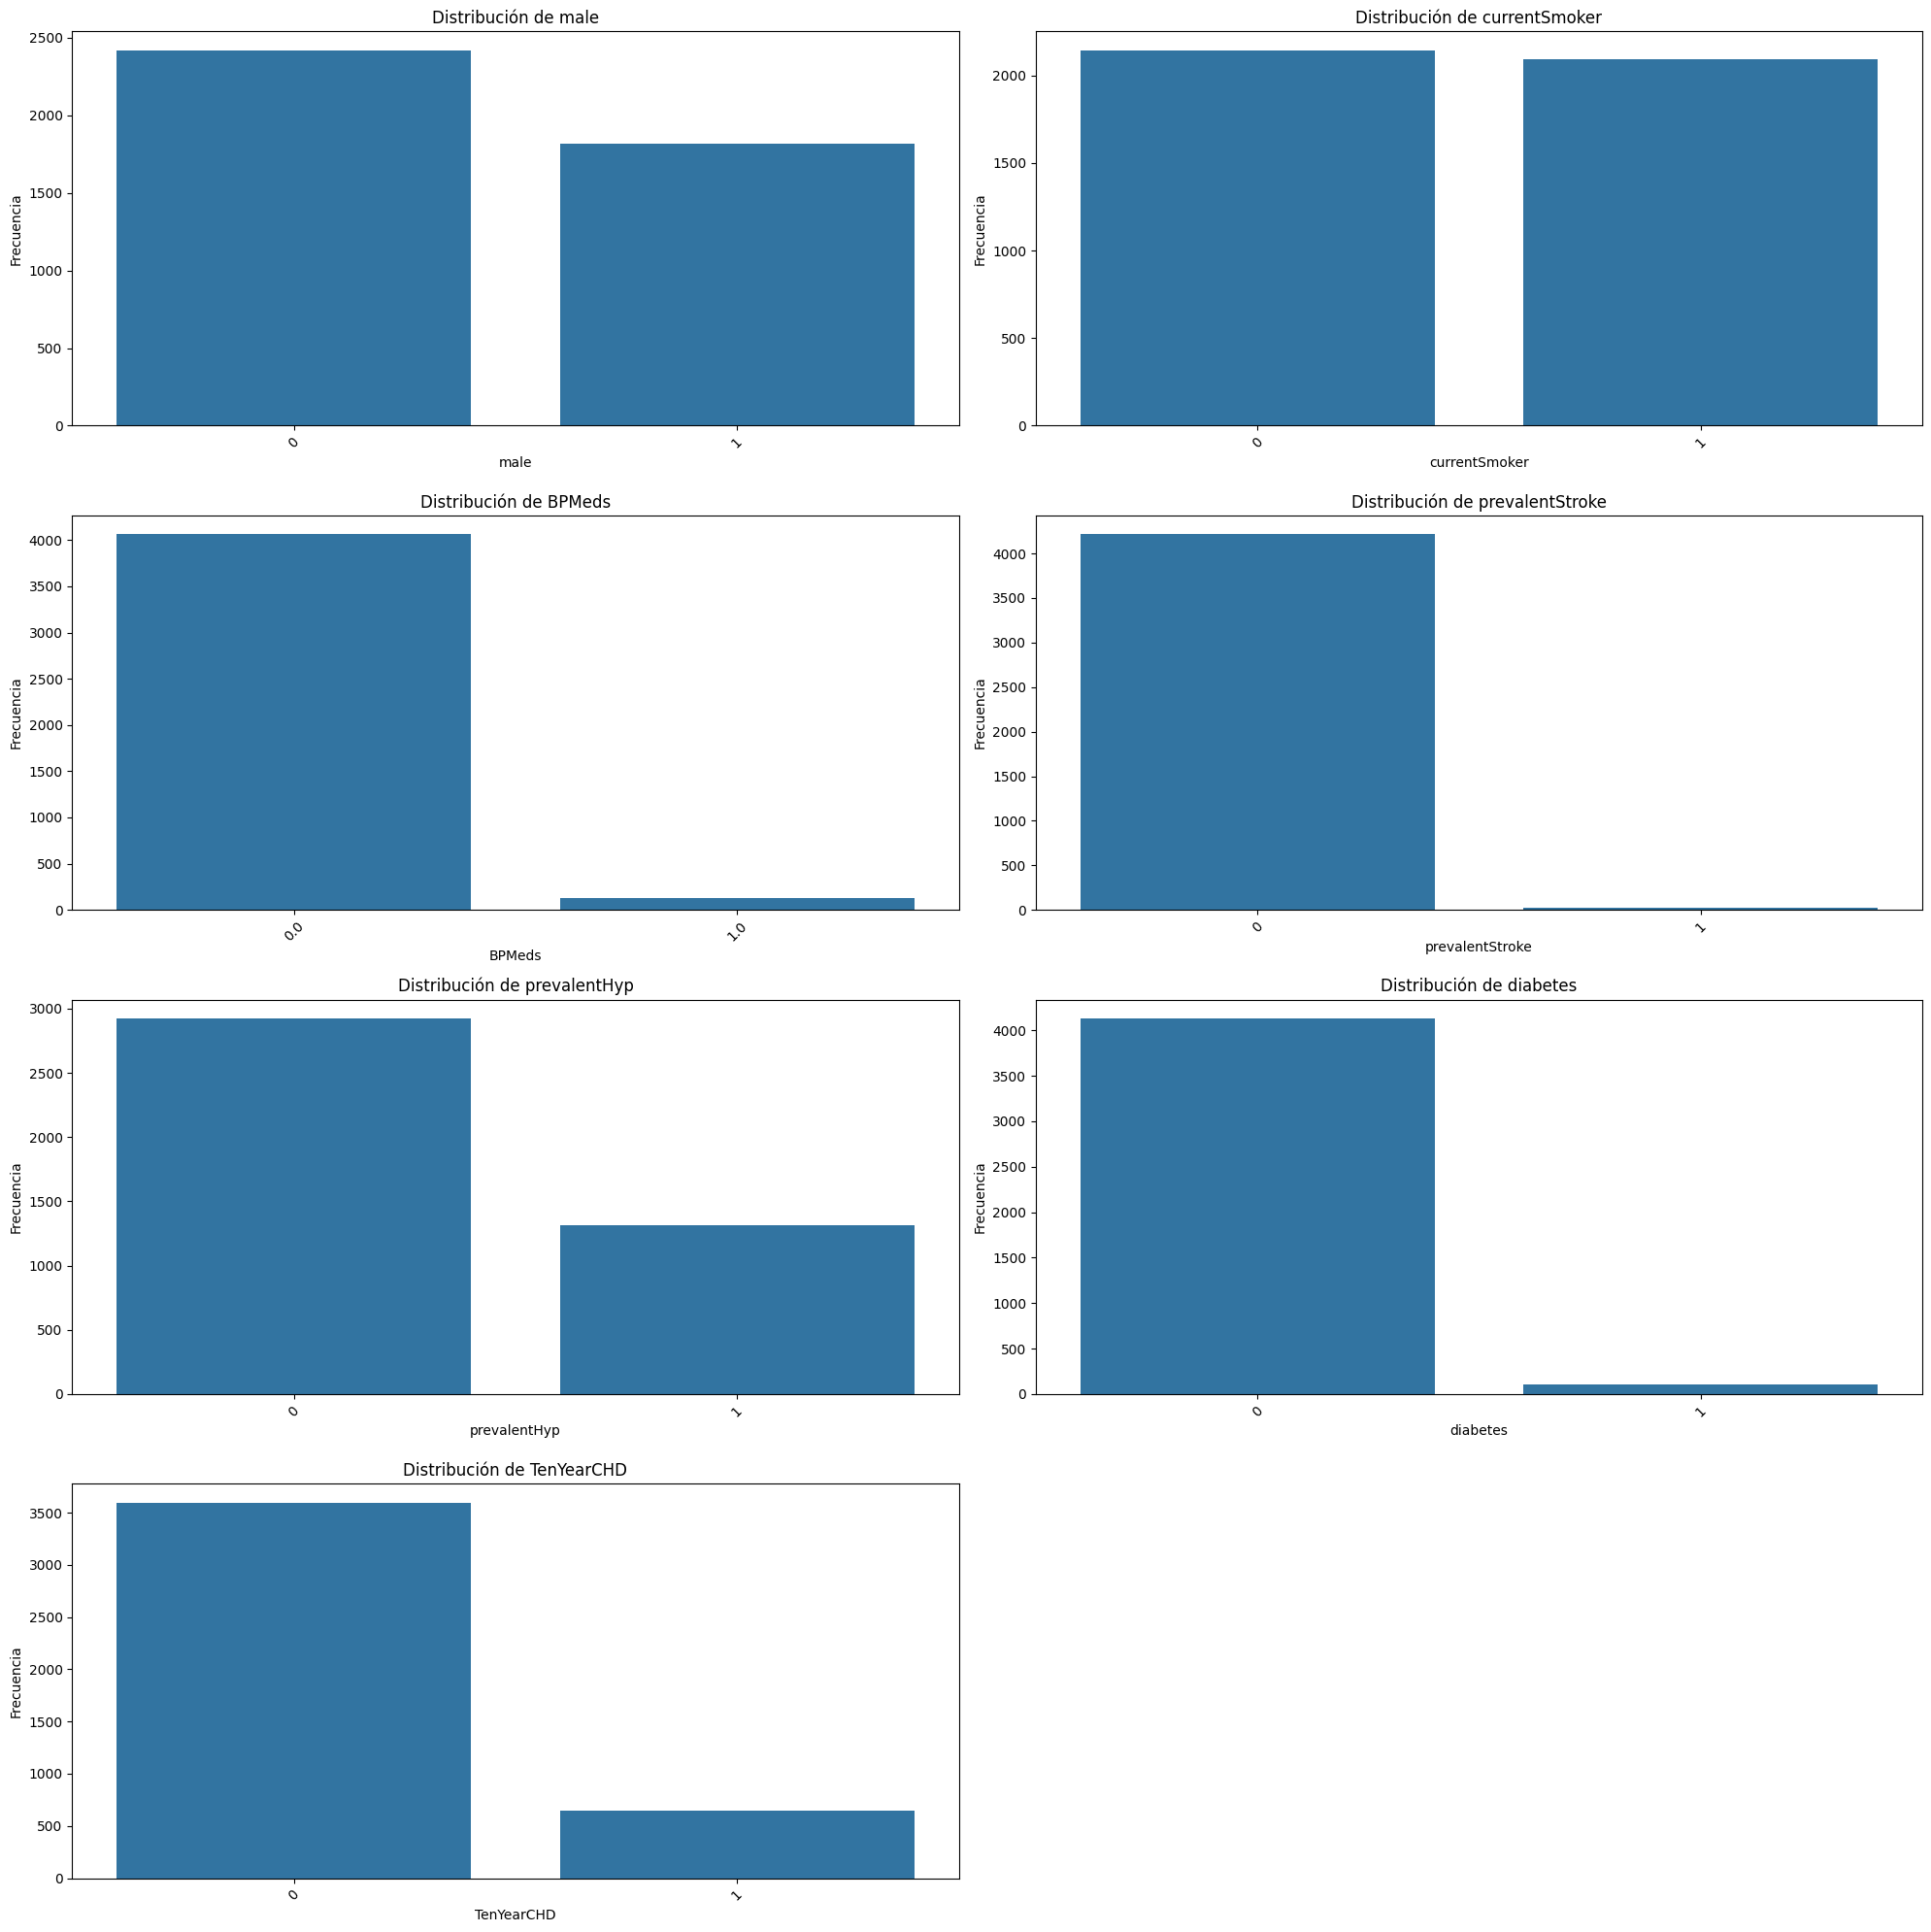

In [19]:


str_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 
            'prevalentHyp', 'diabetes', 'TenYearCHD']

fig, axs = plt.subplots(nrows=len(str_cols) // 2 + len(str_cols) % 2, ncols=2, figsize=(20, 5 * (len(str_cols) // 2 + len(str_cols) % 2)))

# Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

for i, col in enumerate(str_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()



Se puede observar que hay columnas con un claro desbalance, como los pacientes que han sufrido previamente un ictus. También se puede ver en la columna de "diabetes", donde solo una minoria la padece. Cabe resaltar que tenemos una variable objetivo está considerablemente desbalanceada, estando la mayoría de las personas fuera de riesgo de padecer enfermedad coronaria.

### Tratamiento de nulos y outliers para posterior visualización

#### Nulos

In [21]:
df['glucose'] = df['glucose'].fillna(df['glucose'].median())
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
#imputaremos por la mediana las variables que no sean binarias

In [22]:
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])

#para las variables binarias, imputaremos los nulos con la moda 

C:\Users\User\AppData\Local\Temp\ipykernel_1148\2903789269.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])


In [23]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


#### Outliers

In [ ]:
from scipy.stats.mstats import winsorize #esta windsorizacion me la ha hecho la IA

num_cols_outliers = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

for col in num_cols_outliers:
    # Calculamos los límites (Percentil 1 y 99)
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    
    # Aplicamos la Windsorización: 
    # Valores < p1 se vuelven p1, valores > p99 se vuelven p99
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Windsorización completada para las variables numéricas.")

Windsorización completada para las variables numéricas.


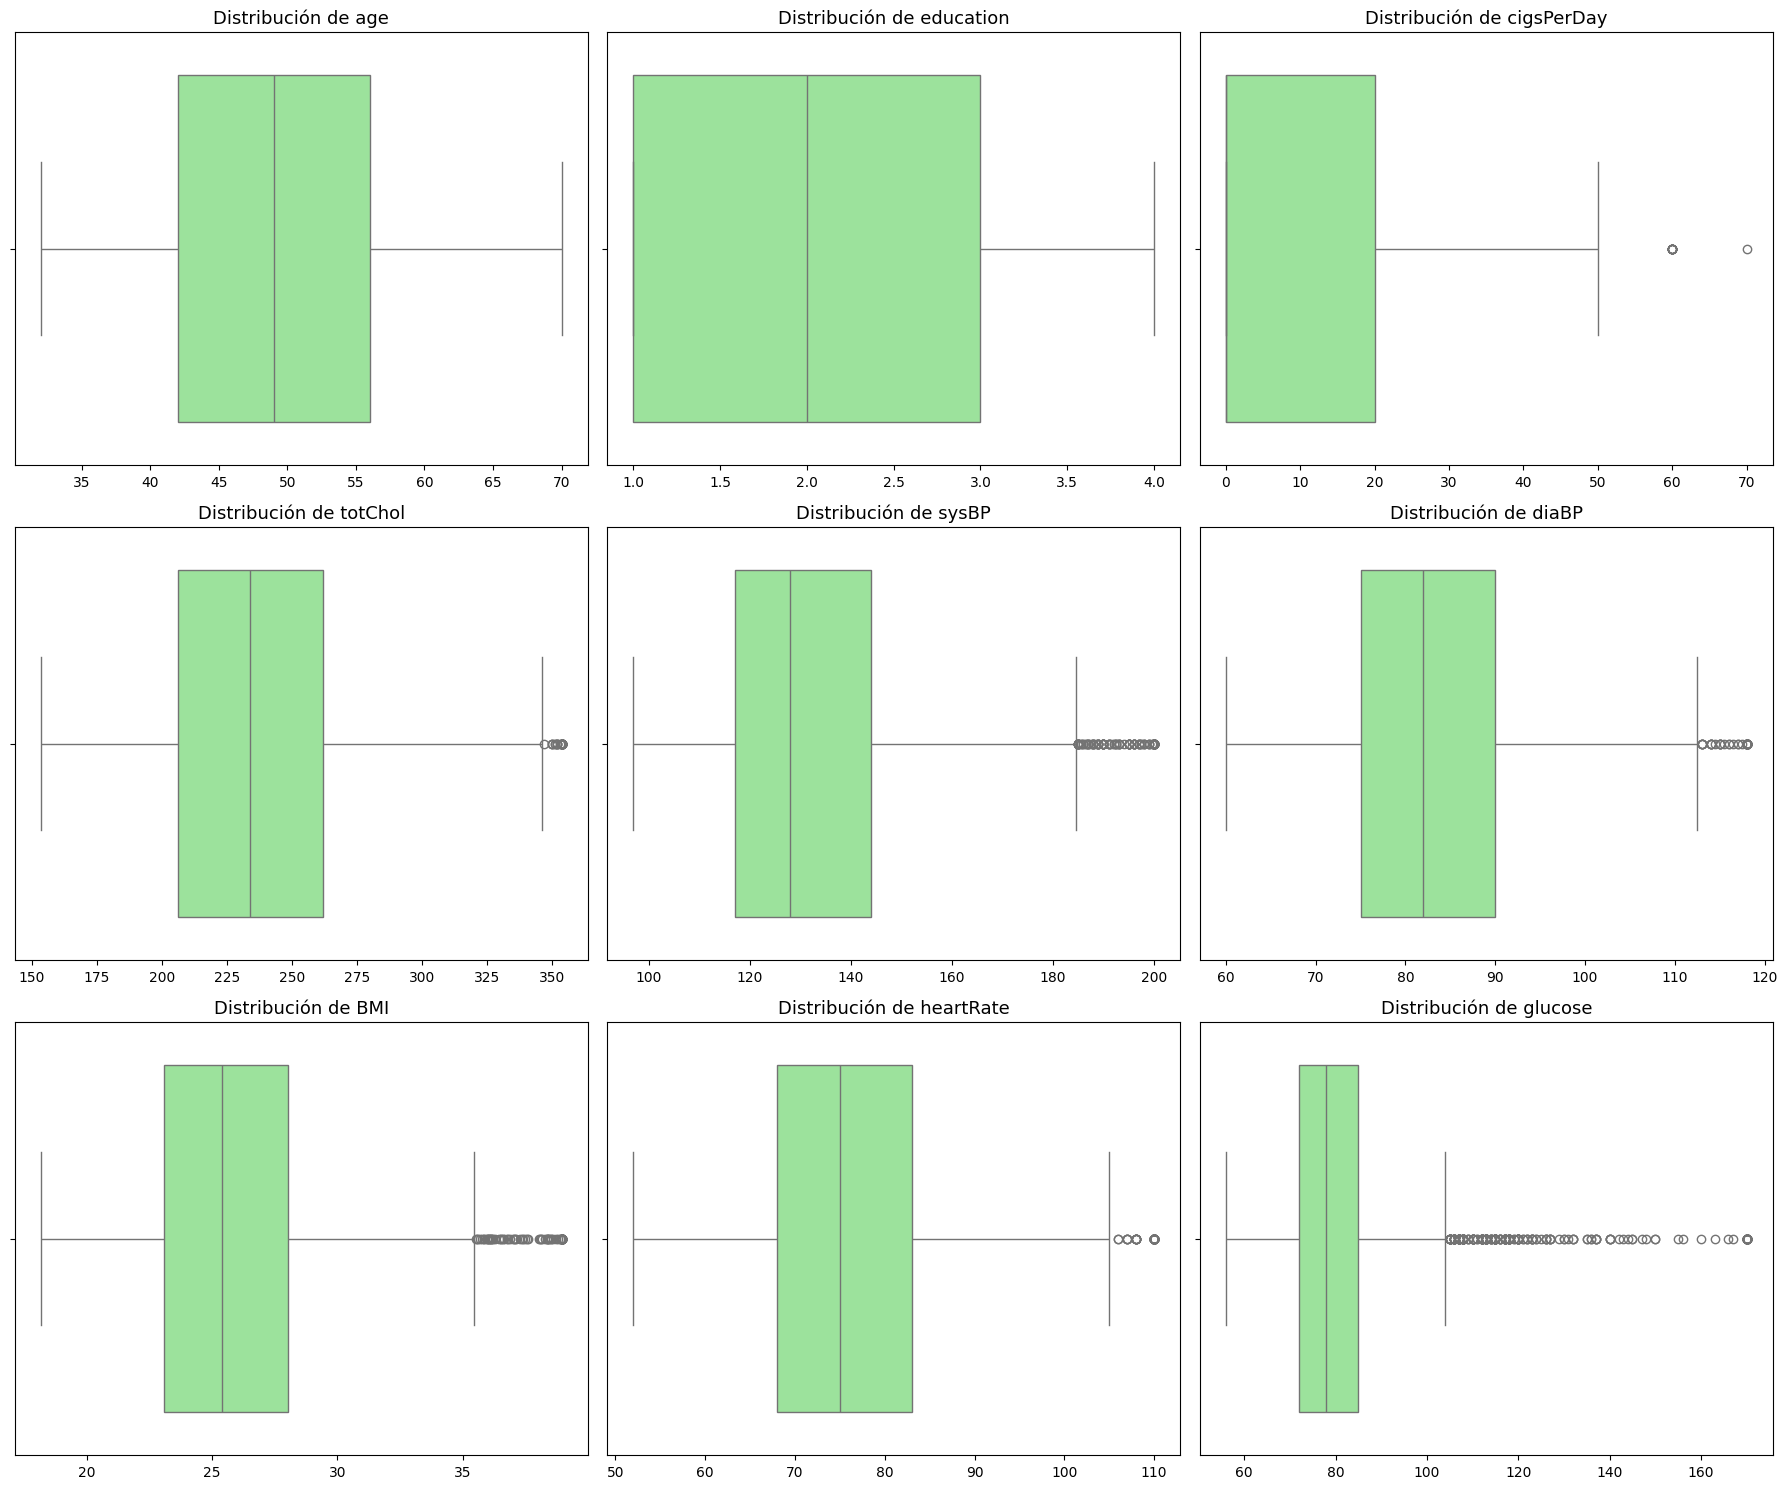

In [25]:
no_binarias = [col for col in df.columns if df[col].nunique() > 2]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(no_binarias):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', fliersize=6)
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

Después de windsorizar, vemos que hay variables cuyo boxplot ha cambiado, siendo la caja mas visible, pero vemos que siguen habiendo outliers. Vamos a imputar el percentil 95, a ver si hay un cambio mas significativo

In [ ]:

num_cols_outliers = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

for col in num_cols_outliers:
    
    lower_limit = df[col].quantile(0.05)
    upper_limit = df[col].quantile(0.95)
    #imputamos el cuartil 0.95
    
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Windsorización completada al percentil 95 para las variables numéricas.")

Windsorización completada al percentil 95 para las variables numéricas.


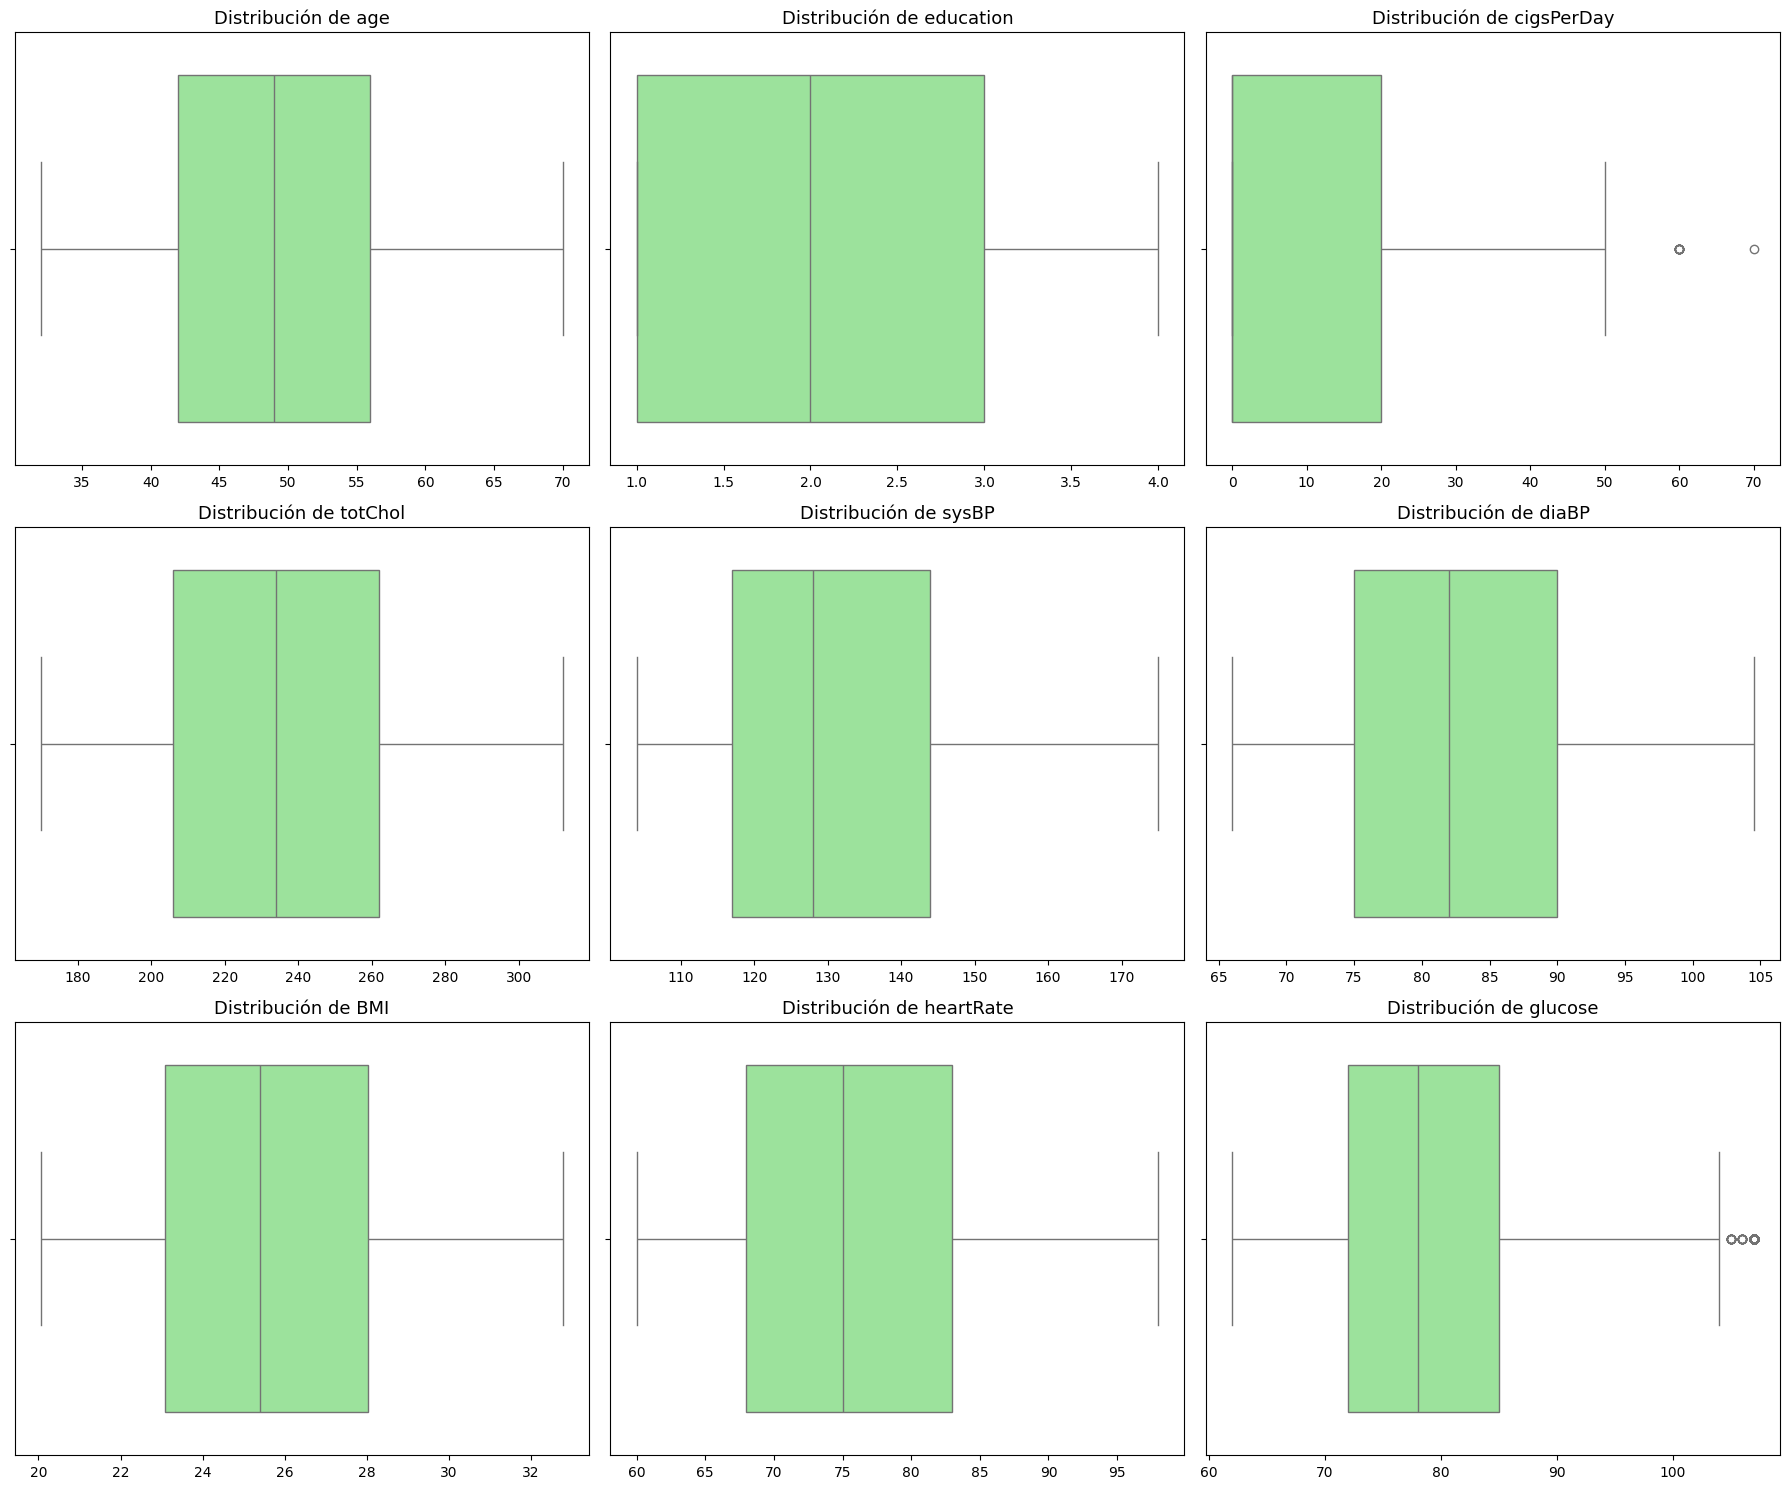

In [43]:
no_binarias = [col for col in df.columns if df[col].nunique() > 2]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(no_binarias):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', fliersize=6)
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

Podemos ver que ahora los boxplots son mucho mas visualizables, especialmente la distribución de glucosa, presion diastólica, ritmo cardiaco, y BMI

## Análisis bivariante respecto al Target

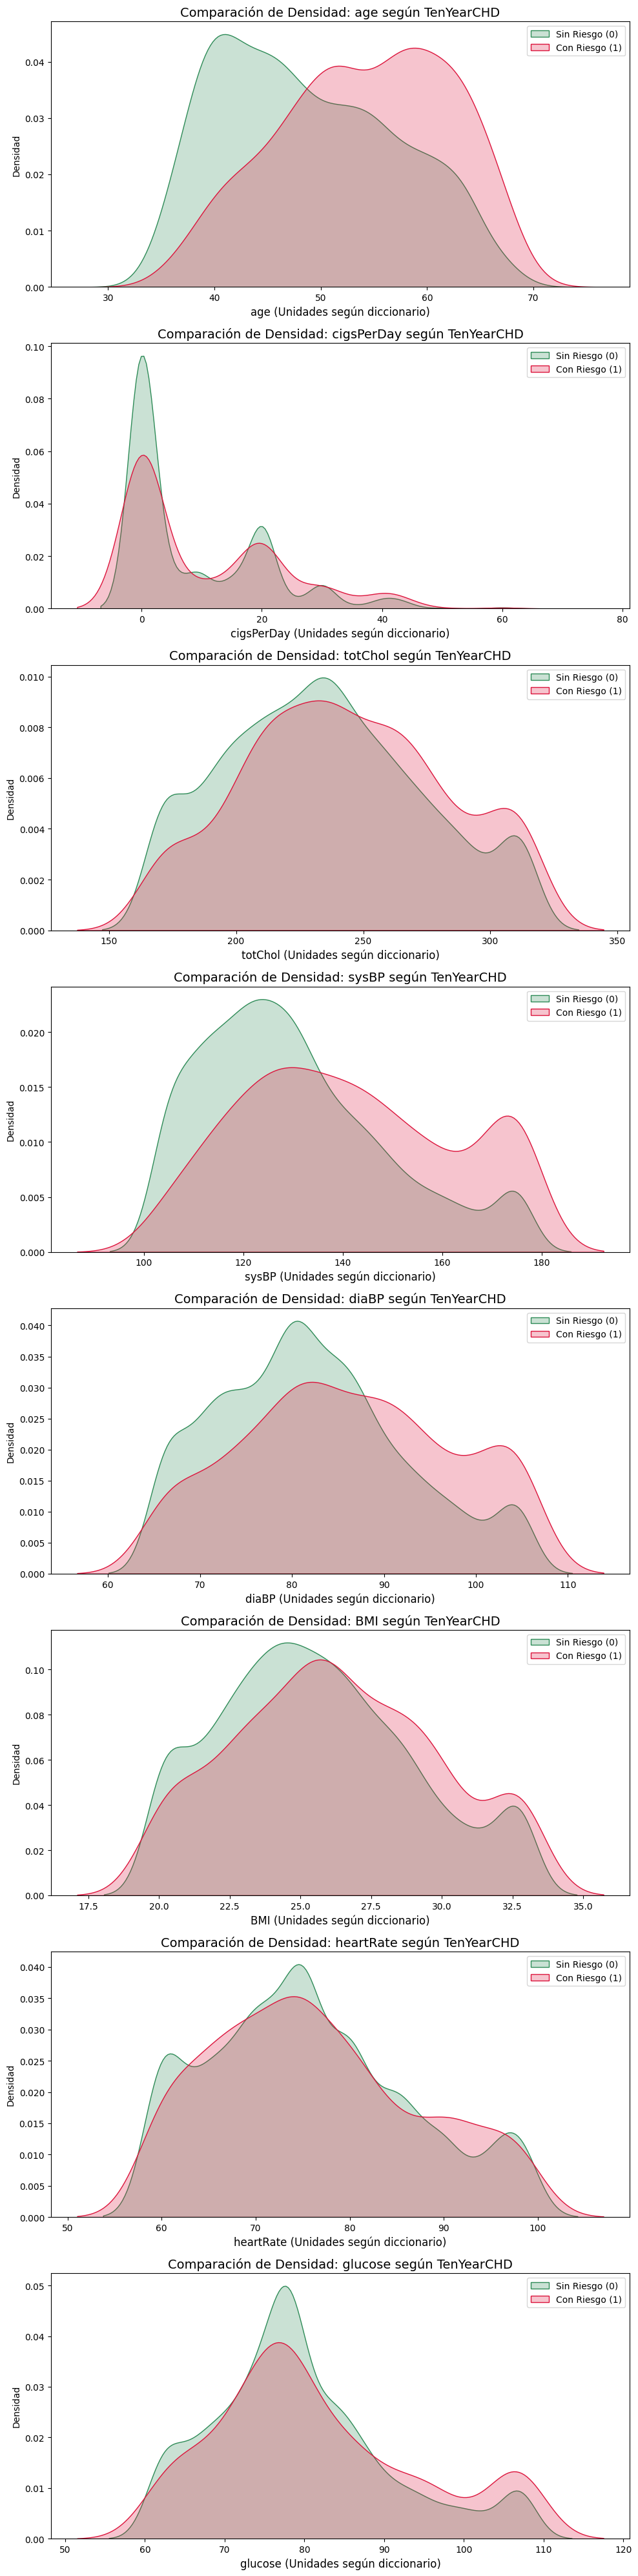

In [44]:


target = 'TenYearCHD'

numeric_cols_to_plot = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


fig, axs = plt.subplots(nrows=len(numeric_cols_to_plot), ncols=1, figsize=(10, 5 * len(numeric_cols_to_plot)))


for i, col in enumerate(numeric_cols_to_plot):
    
    sns.kdeplot(data=df[df[target] == 0], x=col, ax=axs[i], label='Sin Riesgo (0)', fill=True, color='seagreen')
    
    
    sns.kdeplot(data=df[df[target] == 1], x=col, ax=axs[i], label='Con Riesgo (1)', fill=True, color='crimson')
    
   
    axs[i].set_title(f'Comparación de Densidad: {col} según {target}', fontsize=14)
    axs[i].set_xlabel(f'{col} (Unidades según diccionario)', fontsize=12)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

Me ha llamado la atención la comparación de la edad y la variable objetivo, vamos a verla un poco mas detallada.

In [45]:

df.groupby('TenYearCHD')['heartRate'].describe()

,count,mean,std,min,25%,50%,75%,max
TenYearCHD,,,,,,,,
0,3596.0,75.693826,10.648955,60.0,68.0,75.0,83.0,98.0
1,644.0,76.302795,10.903076,60.0,68.0,75.0,85.0,98.0


Ha priori no parece haber una diferencia muy notoria, de hecho llama la atención que el primer 25% es igual en los pacientes sanos y los pacientes con riesgo. No parece ser un factor muy determinante a la hora de ver si un paciente es sano o no.

In [48]:

df.groupby('TenYearCHD')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
TenYearCHD,,,,,,,,
0,3596.0,48.762514,8.413963,32.0,42.0,48.0,55.0,70.0
1,644.0,54.145963,8.005663,35.0,48.0,55.0,61.0,70.0


Podemos ver que el la media hay una brecha de edad de casi 6 años ente los pacientes sanos y los pacientes con riesgo, por lo cual he podido notar que la edad es factor mas diferencial respecto a el HeartRate que analizamos previamente

In [47]:

df.groupby('TenYearCHD')['sysBP'].describe()

,count,mean,std,min,25%,50%,75%,max
TenYearCHD,,,,,,,,
0,3596.0,130.050751,18.569049,104.0,116.0,127.0,141.0,175.0
1,644.0,141.329969,21.138628,104.0,125.0,139.0,158.0,175.0


Otro gráfico que me llamó la atención es el de la presión arterial, donde la media de la presión en los pacientes con riesgo de enfermedad coronaria es notoriamente mayor a la de los pacientes sanos. Esto podría indicar que los pacientes con mayor presión arterial sistólica tienen mayor riesgo de enfermedades coronarias.

In [49]:
df.groupby('TenYearCHD')['cigsPerDay'].describe()

,count,mean,std,min,25%,50%,75%,max
TenYearCHD,,,,,,,,
0,3596.0,8.648498,11.675131,0.0,0.0,0.0,20.0,70.0
1,644.0,10.596273,12.999882,0.0,0.0,2.0,20.0,60.0


Comparando el riesgo de desarrollar enfermedad coronaria con la cantidad de cigarros fumados al día, vemos que los pacientes de riesgo consumen de media 2 cigarrillos más por día, esto da a entender que de alguna forma el consumo de tabaco puede ser un factor de riesgo para las personas a la hora de desarrollar enfermedades coronarias.

## Análisis de las categóricas respecto a la variable objetivo (Bivariante)

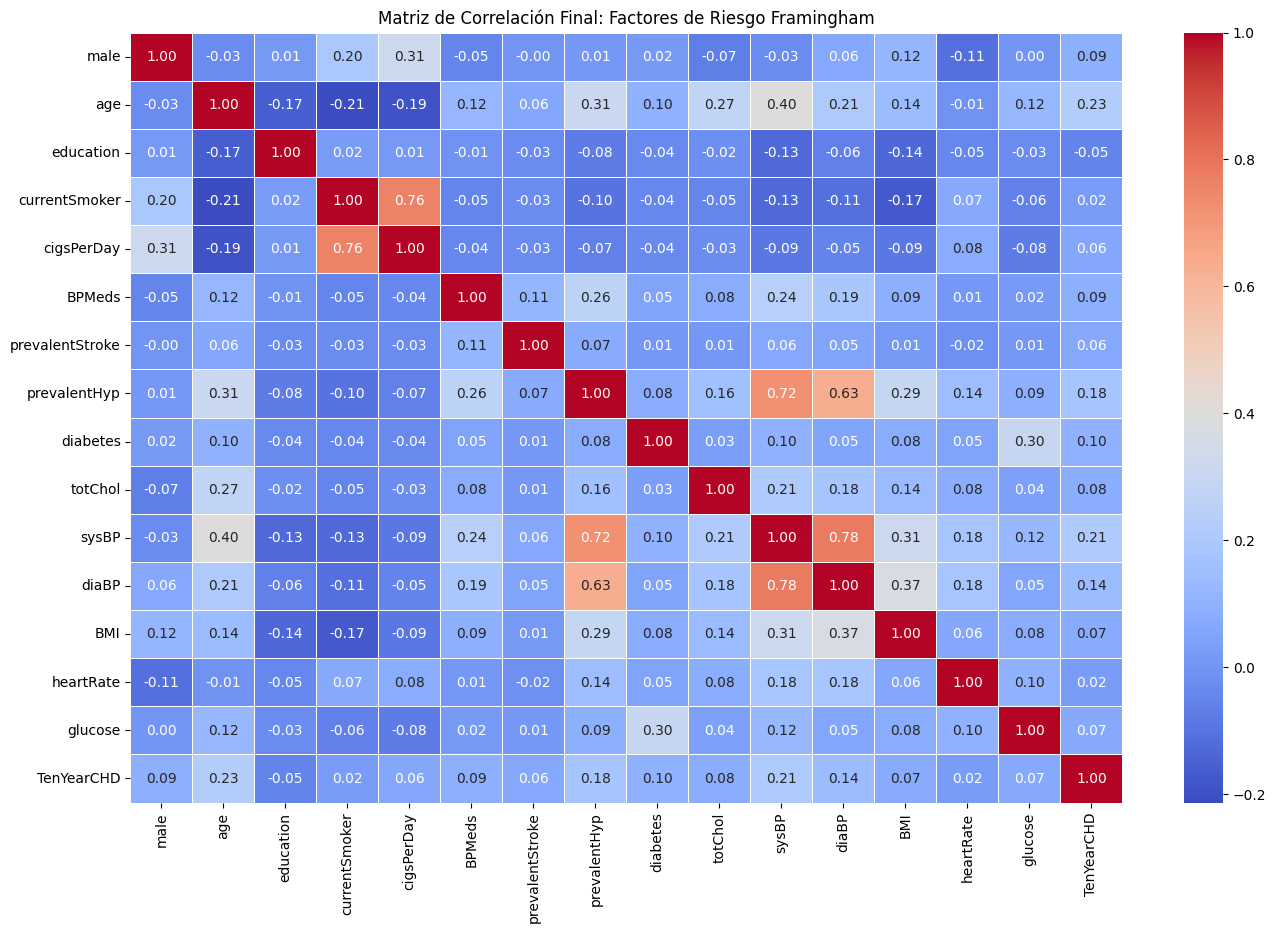

In [50]:
df_corr = df.apply(pd.to_numeric)


plt.figure(figsize=(16, 10))
matriz = df_corr.corr()


sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación Final: Factores de Riesgo Framingham')
plt.show()

Acá podemos notar variables que podrían tener multicolinealidad. Por ejemplo, podemos ver que hay una relaciín significativa entre la cantidad de cigarrillos fumados por día, y si la persona es actualmente fumadura si o no. También podemos ver que hay relación significativa entre la presión arterial sistólica, presión arterial diastólica, y si el paciente tiene hipertensión diagnosticada si o no. Los casos mencionados son variables que podrían tener información redundante.

In [51]:
from sklearn.feature_selection import mutual_info_classif, RFE, RFECV
from sklearn.feature_selection import mutual_info_regression

mi_sys = mutual_info_classif(df[['sysBP']], df['prevalentHyp'].astype(int), discrete_features=[False])[0]
mi_cigs = mutual_info_classif(df[['cigsPerDay']], df['currentSmoker'].astype(int), discrete_features=[True])[0]
mi_bp = mutual_info_regression(df[['diaBP']], df['sysBP'], random_state=42)[0]
print(f"Información Mutua sysBP - prevalentHyp: {mi_sys:.4f}")
print(f"Información Mutua cigsPerDay - currentSmoker: {mi_cigs:.4f}")
print(f"Información Mutua entre diaBP y sysBP: {mi_bp:.4f}")

Información Mutua sysBP - prevalentHyp: 0.3237
Información Mutua cigsPerDay - currentSmoker: 0.6568
Información Mutua entre diaBP y sysBP: 0.5304


Vemos que en la información mutua, las variables mencionadas anteriormente se explican mutuamente en un nivel considerable.

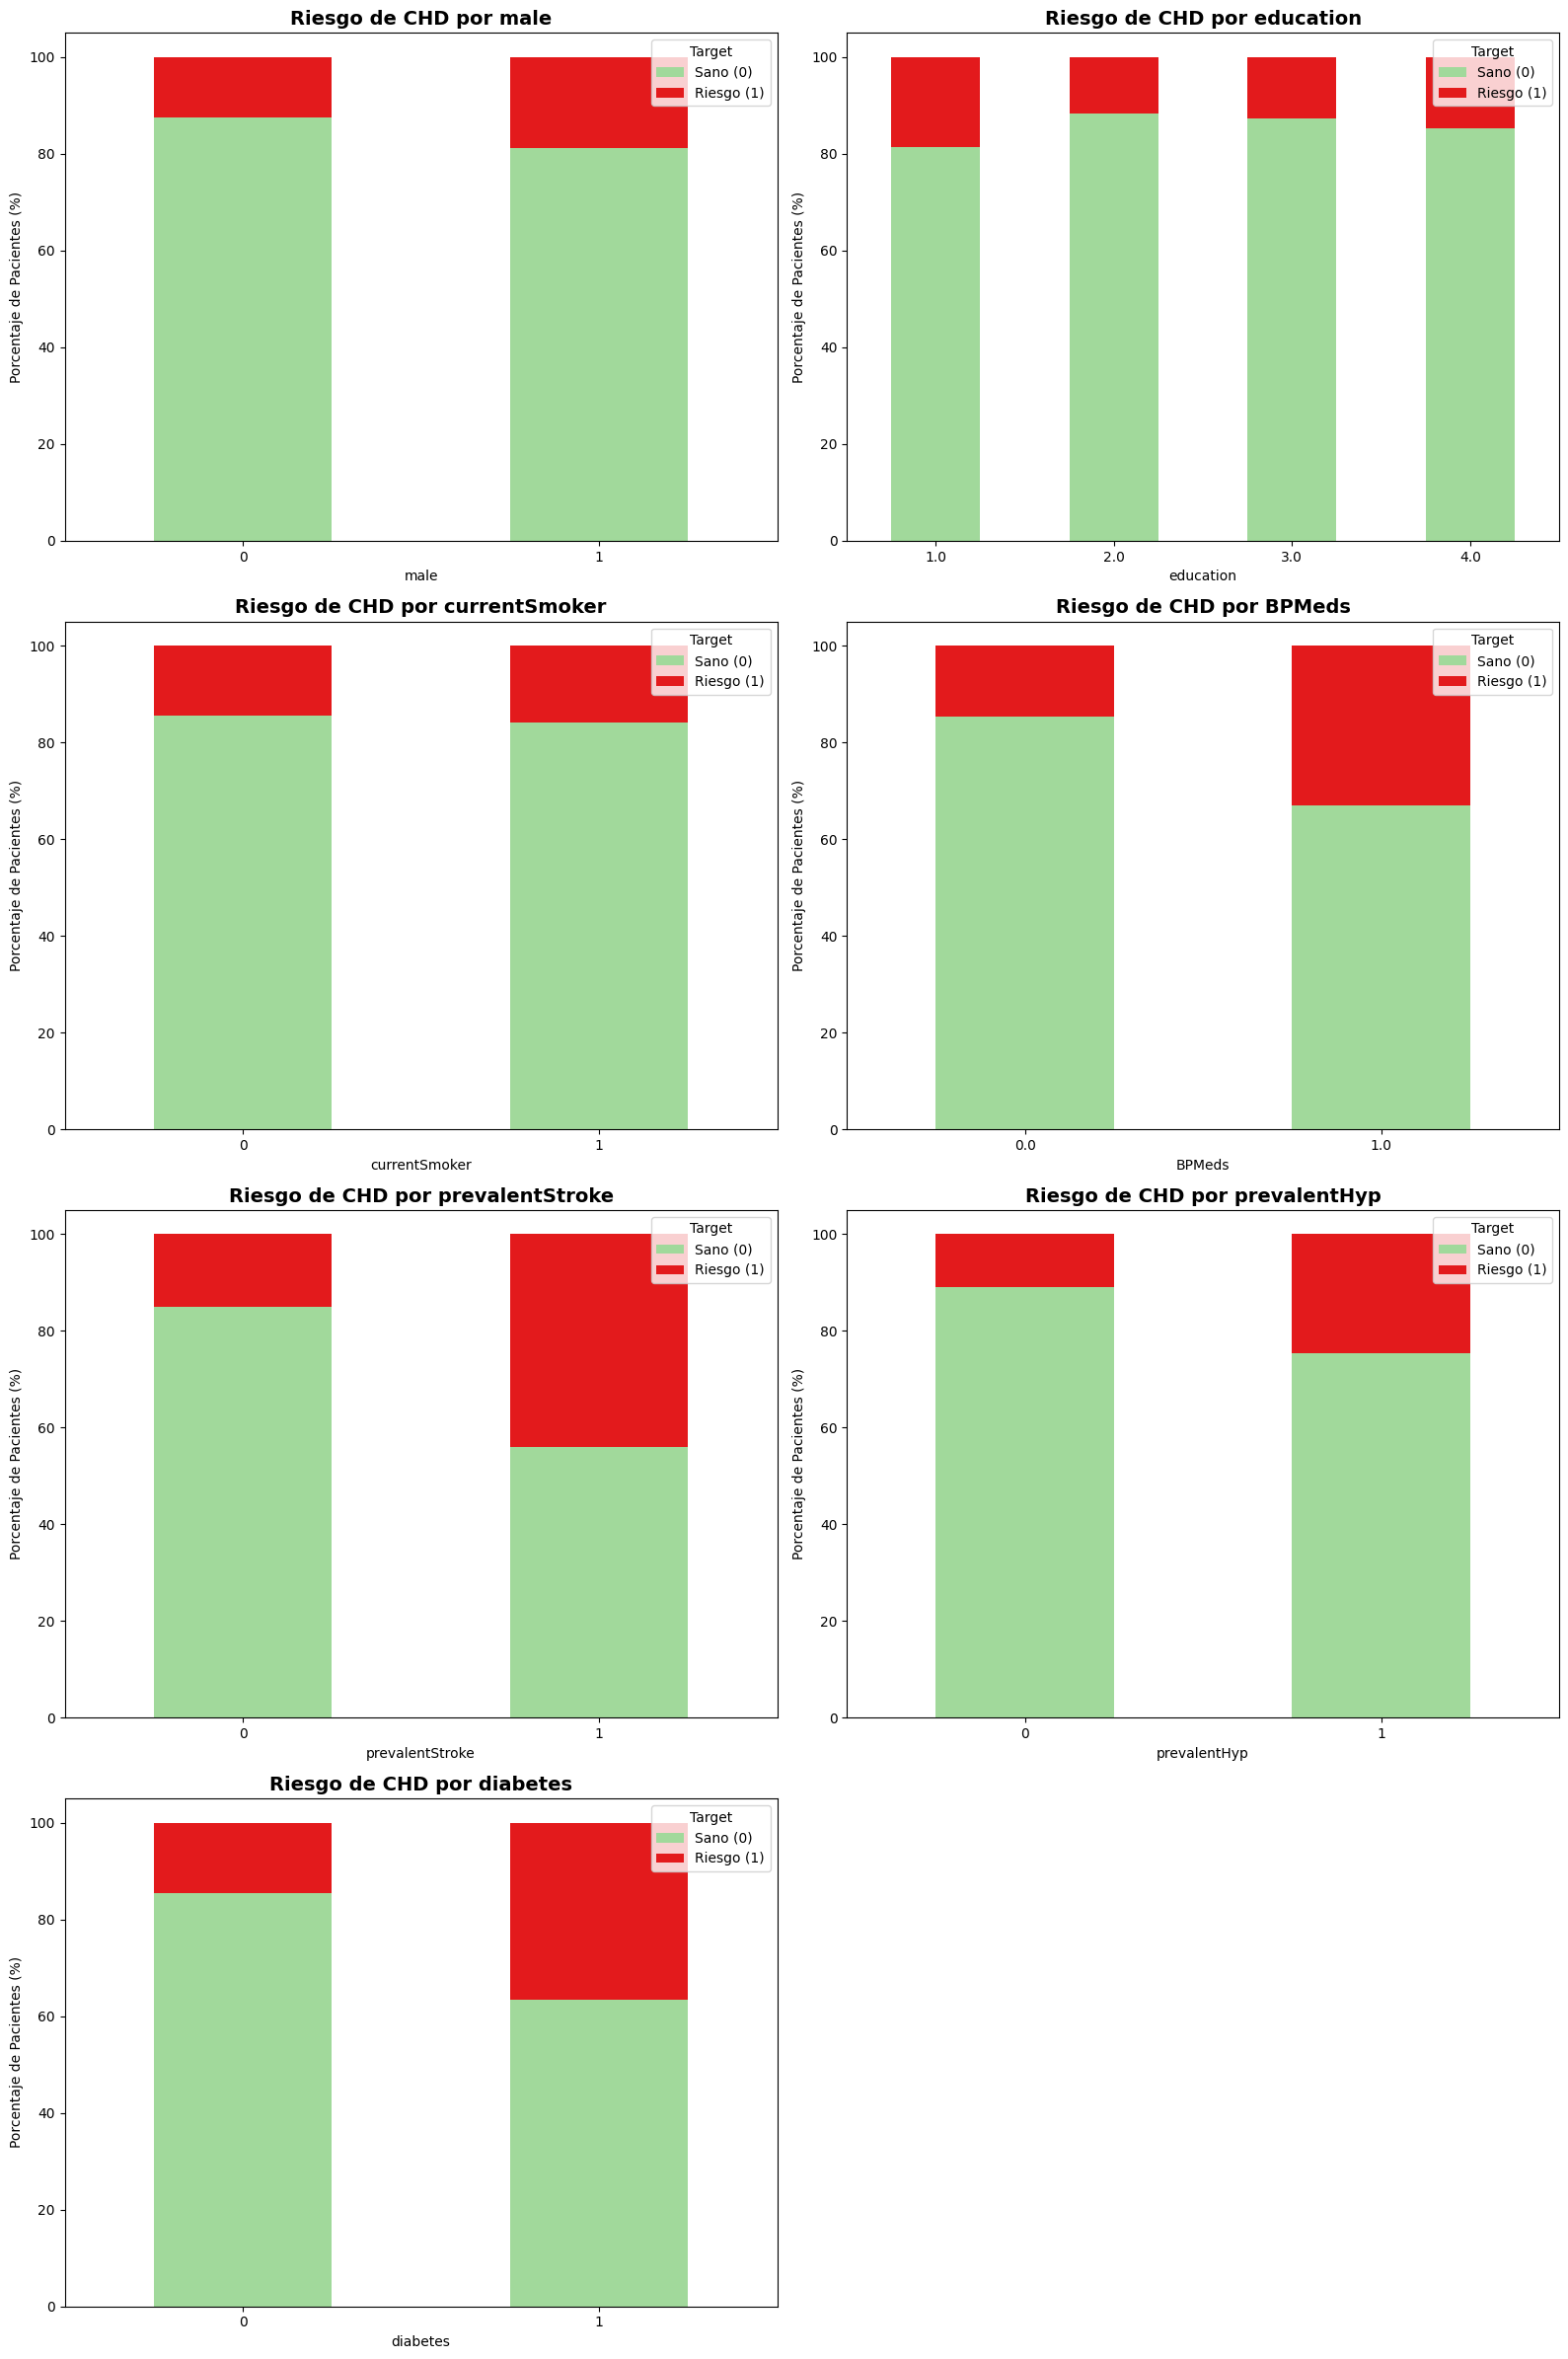

In [52]:
cat_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
target = 'TenYearCHD'

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    cross_tab = pd.crosstab(df[col], df[target], normalize='index') * 100
    
    # 
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#a1d99b', '#e31a1c'])
    
   
    axes[i].set_title(f'Riesgo de CHD por {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Porcentaje de Pacientes (%)')
    axes[i].set_xlabel(col)
    axes[i].legend(['Sano (0)', 'Riesgo (1)'], loc='upper right', title='Target')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)


if len(cat_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En estos gráficos podemos ver cosas bastante interesantes, pero vamos por partes.

H1: ¿Tienen las mujeres mas riesgo de desarrollar enfermedades coronarias?

En el gráfico podemos ver que los hombres tienen una tendencia ligeramente mayor a desarrollar enfermedades coronarias respecto a las mujeres, ya que vemos que el area roja (personas que han desarrolado enfermedades coronarias después de 10 años) en hombres el ligeramente más grande.

H2: ¿Influye el nivel de educación en el riesgo de desarrollar enfermedad coronaria?

En el gráfico se puede ver que las diferencias son minimas, siendo ligeramente mayor en las personas sin nivel de educación, pero realmente en las personas con un mayor nivel de educación tienen un riesgo bastante parecido con ligeras fluctuaciones.


H3: ¿Tienen los fumadores mayor riesgo de desarrollar CHD después de 10 años?

Los gráficos indican que el riesgo es mayor, pero honestamente me esperaba una diferencia mucho mayor. Los pacientes fumadores tienen un mayor riesgo de enfermedad coronaria.


H4: ¿Los pacientes en medicación por presión arterial tienen mayor riesgo a desarrollar CHD? 

El gráfico demuestar que entre los pacientes que están en tratamiento por presión arterial, hay un mayor porcentaje que ha desarrolado CHD depués de 10 años sobre los que no se medican.

H5: ¿Los pacientes que han tenido un ictus tienen mas riesgo a desarrollar CHD después de 10 años?

Según el gráfico, el riesgo aumenta considerablemente, los pacientes que han tenido un ictus son más propensos a desarrollar CHD sobre los pacientes que no han sufrido un ictus.

H6: ¿Los pacientes con hipertensión diagnosticada son mas propensos a desarrollar CHD?

Los datos indican que los pacientes que los pacientes con hipertensión diagnosticada son más propensos a desarrollar CHD, sobre los que no. 

H7: ¿Es la diabetes un factor de riego a la hora de desarrollar CHD?

Sorpresivamente los pacientes que padecen de diabetes tienen un riesgo considerablemente mayor a desarrollar CHD sobre los pacientes que no padecen de diabetes. Me sorprendió que según los gráficos la diabetes es un factor de riesgo mayor a ser fumador, no me lo esperaba.
